In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("chapter7_assets/3_normal_distribution/heights.csv")
df.head()

,name,height
0,Aarav,5.45
1,Deepika,5.61
2,Abhishek,5.65
3,Sneha,5.52
4,Kriti,5.69


In [5]:
df.shape

(1000, 2)

In [13]:
mean=round(df["height"].mean(),2)
std=round(df["height"].std(),2)
mean,std

(5.61, 0.33)

C:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


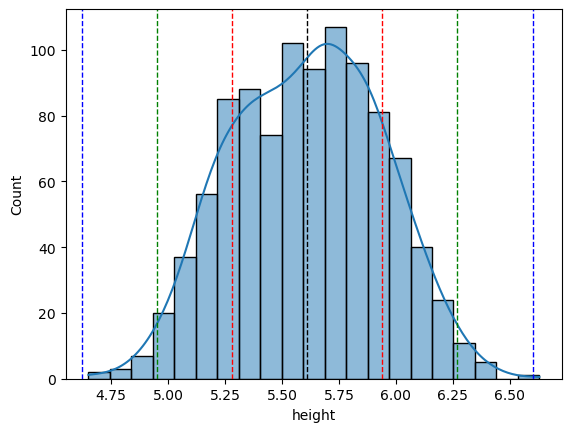

In [19]:
sns.histplot(df["height"],kde=True) # kde=kernel density estimator for ploting line

# ploting mean line
plt.axvline(mean, color="black", linestyle="dashed", linewidth=1)

# !st std line
plt.axvline(mean+std,color="r", linestyle="dashed",linewidth=1)
plt.axvline(mean-std,color="r", linestyle="dashed",linewidth=1)
# 2nd std line
plt.axvline(mean+2*std,color="g", linestyle="dashed",linewidth=1)
plt.axvline(mean-2*std,color="g", linestyle="dashed",linewidth=1)

# 3rd std line
plt.axvline(mean+3*std,color="blue", linestyle="dashed",linewidth=1)
plt.axvline(mean-3*std,color="blue", linestyle="dashed",linewidth=1)

In [25]:
left1=round(mean-std,2)
right1=round(mean+std,2)

left2=round(mean-2*std,2)
right2=round(mean+2*std,2)

left3=round(mean-3*std,2)
right3=round(mean+3*std,2)

In [26]:
# data falls in 1st left and 1st right
df[(df["height"]>left1)&(df["height"]<right1)].shape

(641, 2)

In [23]:
df[(df["height"]>left2)&(df["height"]<right2)].shape

(970, 2)

In [24]:
df[(df["height"]>left3)&(df["height"]<right3)].shape

(999, 2)

## 7.4 Detect outliers

In [2]:
df=pd.read_csv("chapter7_assets/4_detect_outliers_using_normal_distribution/heights_with_outliers.csv")
df.head()

,name,height
0,Aarav,5.45
1,Deepika,8.20
2,Abhishek,5.65
3,Sneha,5.52
4,Kriti,5.69


In [3]:
mean=round(df["height"].mean(),2)
std=round(df["height"].std(),2)
mean,std

(5.61, 0.37)

C:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


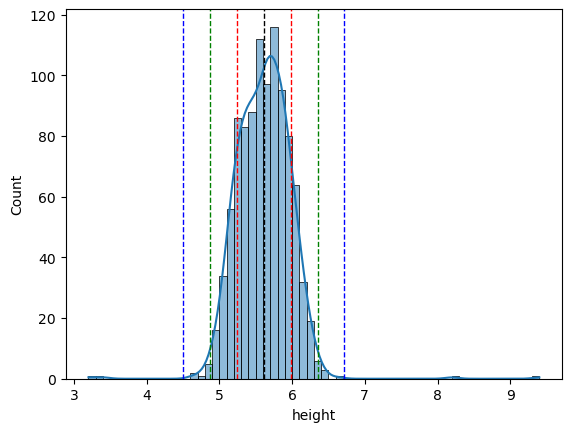

In [8]:
sns.histplot(df["height"],kde=True) # kde=kernel density estimator for ploting line

# ploting mean line
plt.axvline(mean, color="black", linestyle="dashed", linewidth=1)

# !st std line
plt.axvline(mean+std,color="r", linestyle="dashed",linewidth=1)
plt.axvline(mean-std,color="r", linestyle="dashed",linewidth=1)
# 2nd std line
plt.axvline(mean+2*std,color="g", linestyle="dashed",linewidth=1)
plt.axvline(mean-2*std,color="g", linestyle="dashed",linewidth=1)

# 3rd std line
plt.axvline(mean+3*std,color="blue", linestyle="dashed",linewidth=1)
plt.axvline(mean-3*std,color="blue", linestyle="dashed",linewidth=1)

In [9]:
# finding lower and upper limit using mean and std
lower=mean-3*std
upper=mean+3*std
lower,upper

(4.5, 6.720000000000001)

In [10]:
df[(df["height"]<lower)|(df["height"]>upper)]

,name,height
1,Deepika,8.2
16,Tanvi,3.2
57,Priya,3.4
76,Aarav,9.4


In [11]:
df_with_no_out=df[(df["height"]>lower)&(df["height"]<upper)]
df_with_no_out.shape

(996, 2)

## 7.7 Z-Score

In [5]:
# creating a z_score column
df["z_score"]=(df["height"]-mean)/std
df.head()

,name,height,z_score
0,Aarav,5.45,-0.432432
1,Deepika,8.20,7.000000
2,Abhishek,5.65,0.108108
3,Sneha,5.52,-0.243243
4,Kriti,5.69,0.216216


In [6]:
(5.45-mean)/std

-0.43243243243243285

In [8]:
df[(df["z_score"]<-3)|(df["z_score"]>3)]

,name,height,z_score
1,Deepika,8.2,7.000000
16,Tanvi,3.2,-6.513514
57,Priya,3.4,-5.972973
76,Aarav,9.4,10.243243


In [10]:
df_no_outliers=df[(df["z_score"]>-3)&(df["z_score"]<3)]
df_no_outliers.shape

(996, 3)

C:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='height', ylabel='Count'>

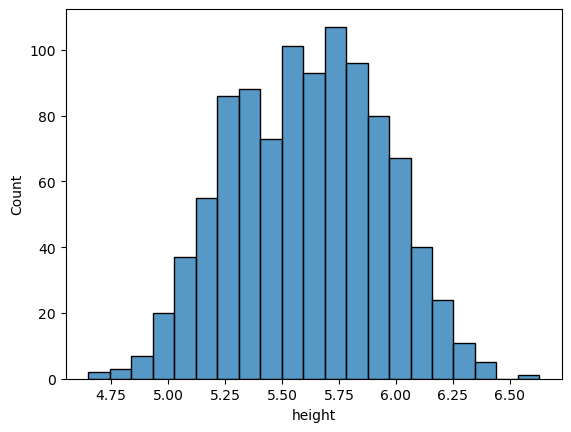

In [11]:
# uniform distribution without outliers
sns.histplot(df_no_outliers["height"])
